This notebook generates figures in [our paper](https://www.biorxiv.org/content/10.1101/2025.10.06.680724v1).

In [2]:
import pandas as pd
import numpy as np
from ete3 import Tree

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

from scipy.stats.distributions import chi2
from scipy.stats import wilcoxon

species_tree_color = "#a1c9f4"
spinney_color = "#8de5a1"

# Load data

In [2]:
!find ../single_rate ../two_rates -type f -name "*1p.tsv" -print0 | xargs -0 cat > one_rate.tsv
!find ../single_rate ../two_rates -type f -name "*2p.tsv" -print0 | xargs -0 cat > two_rate.tsv

In [42]:
rate_1p = pd.read_csv("one_rate.tsv", sep="\t", header=None)
rate_2p = pd.read_csv("two_rate.tsv", sep="\t", header=None)

rate_1p.columns = "num_tree	success	llh	rate	cov_mle	tip_val	condition	trait_idx	time".split()
rate_2p.columns = "num_tree	success	llh	rateA   rateB	cov_mle	tip_val	condition	trait_idx	time".split()

rate_1p.drop_duplicates(['condition', 'trait_idx'],inplace=True)
rate_2p.drop_duplicates(['condition', 'trait_idx'],inplace=True)

rate_1p = rate_1p.sort_values(["condition", "trait_idx"])
rate_2p = rate_2p.sort_values(["condition", "trait_idx"])

conditions = np.concatenate([rate_1p.condition.unique(), rate_2p.condition.unique()])

# Figure 4

## (a)

In [ ]:
selected_conditions = [x for x in conditions if x.startswith("fourtaxa")]

data = rate_1p.loc[rate_1p.condition.isin(selected_conditions)]
data[["condition"]] = data.condition.str.extract(r"fourtaxa_(.+)_.+_.+")

/var/folders/f7/y1wwv8vd5pl_xm3q00hb3ftr0000gn/T/ipykernel_6649/4242195989.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Low", "Medium", "High"])


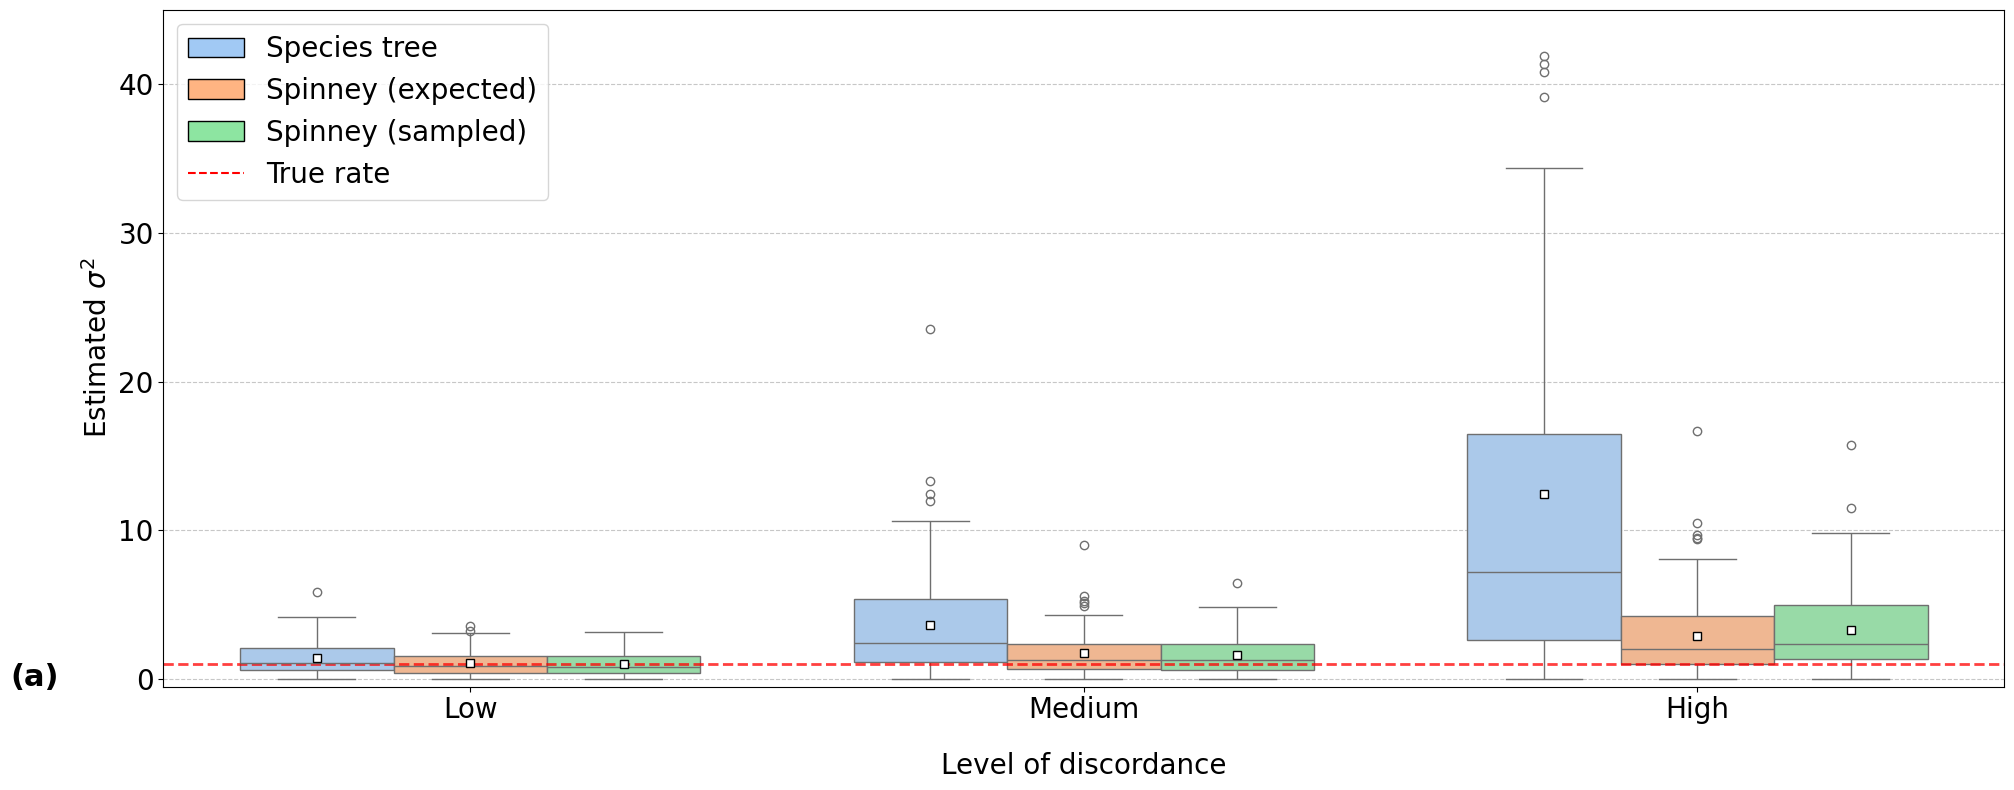

In [106]:
fontsize = 20
cond_order = [k for k,_ in sorted({"low":0,"med":1,"high":2}.items(), key=lambda kv: kv[1])]

plt.figure(figsize=(20,8), dpi=100)
ax = sns.boxplot(
    data=data,
    x="condition",
    y="rate",
    hue="num_tree",
    order=cond_order,
    showmeans=True,
    width=0.75,
    palette="pastel",
    meanprops={'marker':'s','markerfacecolor':'white','markeredgecolor':'black','markersize':'6'},
)

# reference line at true rate = 1
ax.axhline(1, linestyle='--', color='red', linewidth=2, alpha=0.75)
ax.set_xticklabels(["Low", "Medium", "High"])

# labels & ticks
ax.set_xlabel("Level of discordance", fontsize=fontsize, labelpad=20)
ax.set_ylabel(r"Estimated $\sigma^2$", fontsize=fontsize)
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_ylim(-0.5, 45)


legend_map = {
    "1": "Species tree",
    "4": "Spinney (expected)",
    "20": "Spinney (sampled)"
}



line_handle = mlines.Line2D([], [], color="red", linestyle="--", label="True rate")
box_A = mpatches.Patch(facecolor=species_tree_color, edgecolor="black", label="Species tree")
box_B = mpatches.Patch(facecolor="#ffb482", edgecolor="black", label="Spinney (expected)")
box_C = mpatches.Patch(facecolor=spinney_color, edgecolor="black", label="Spinney (sampled)")

ax.legend(handles=[box_A, box_B, box_C, line_handle], fontsize=fontsize, loc="upper left")


ax.text(-0.75, 1.05, "(a)", ha='left', va='top', fontsize=22, fontweight='bold')

plt.grid(True, axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


## (b) and (c)

In [ ]:
selected_conditions = [x for x in conditions if x.startswith("performance")]

pattern = r"performance_(\d+)_sampled_1p"

data = rate_1p[rate_1p.condition.str.extract(pattern, expand=False).notna()]
data[["num_taxa"]] = data.condition.str.extract(r"performance_(\d+)_sampled_1p")
data[["num_taxa"]] = data[["num_taxa"]].astype(int)

cond_order = np.sort( data["num_taxa"].unique())

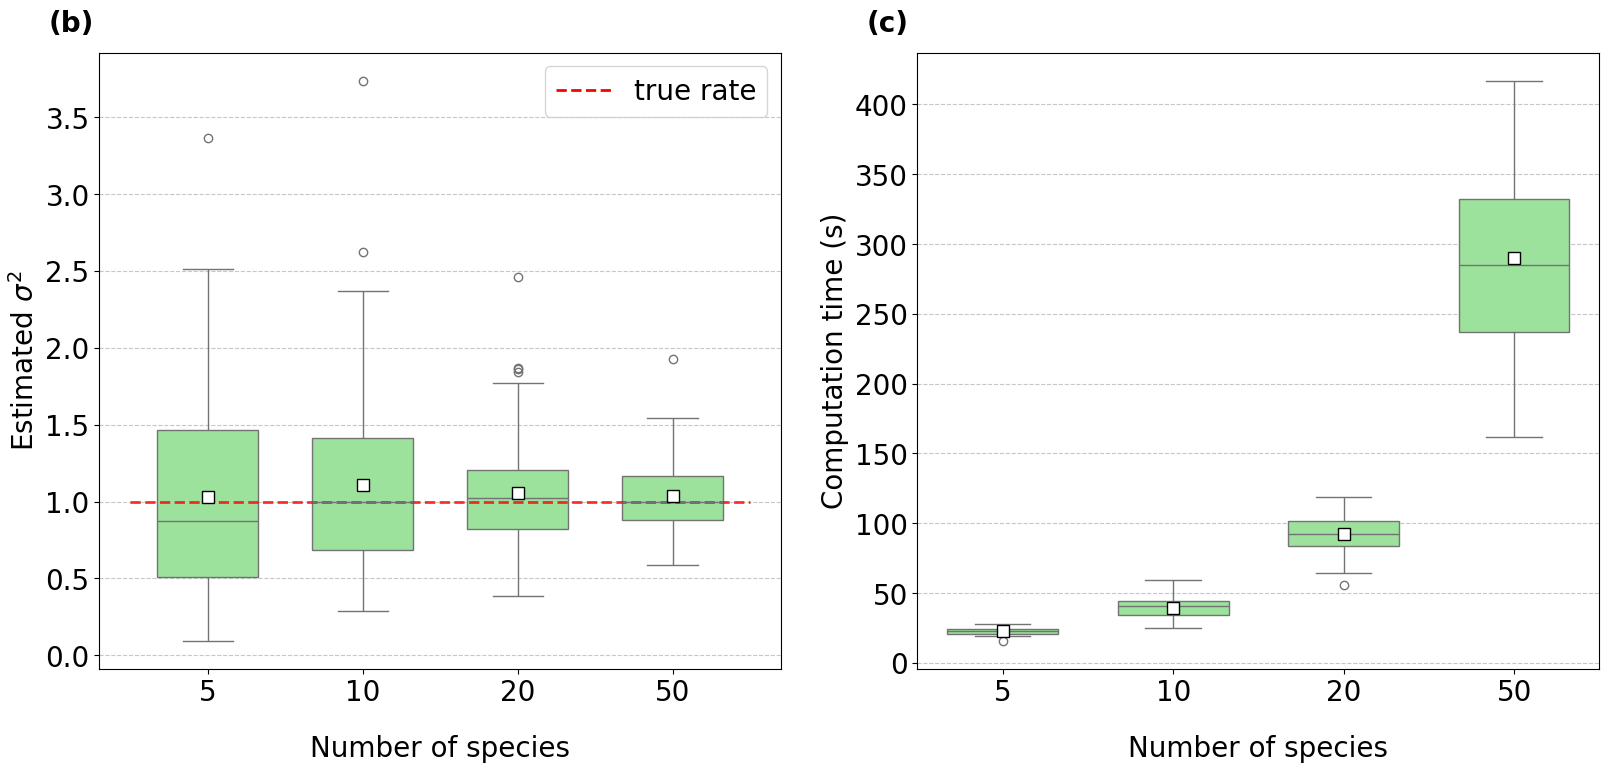

In [117]:
fontsize = 20
fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=100, sharex=False)

# panel (b): sigma^2 
sns.boxplot(
    data=data,
    x="num_taxa",
    y="rate",
    hue="num_tree",
    showmeans=True,
    width=0.65,
    palette=["lightgreen"],
    meanprops={'marker': 's', 'markerfacecolor': 'white',
               'markeredgecolor': 'black', 'markersize': '8'},
    legend=False,
    order = cond_order,
    ax=axes[0]
)

axes[0].plot([-0.5, 3.5], [1, 1], 'r--', linewidth=2, label="true rate", alpha=0.8)
axes[0].set_xlabel("Number of species", fontsize=fontsize, labelpad=20)
axes[0].set_ylabel(r"Estimated $\sigma^2$", fontsize=fontsize)
axes[0].tick_params(axis='x', labelsize=fontsize)
axes[0].tick_params(axis='y', labelsize=fontsize)
axes[0].grid(True, axis='y', linestyle="--", alpha=0.7)
axes[0].text(-0.075, 1.07, "(b)", transform=axes[0].transAxes,
             ha='left', va='top', fontsize=20, fontweight='bold')

# panel (c): time 
sns.boxplot(
    data=data,
    x="num_taxa",
    y="time",
    hue="num_tree",
    showmeans=True,
    width=0.65,
    palette=["lightgreen"],
    meanprops={'marker': 's', 'markerfacecolor': 'white',
               'markeredgecolor': 'black', 'markersize': '8'},
    legend=False,
    order = cond_order,
    ax=axes[1]
)
axes[1].set_xlabel("Number of species", fontsize=fontsize, labelpad=20)
axes[1].set_ylabel("Computation time (s)", fontsize=fontsize)
axes[1].tick_params(axis='x', labelsize=fontsize)
axes[1].tick_params(axis='y', labelsize=fontsize)
axes[1].grid(True, axis='y', linestyle="--", alpha=0.7)
axes[1].text(-0.075, 1.07, "(c)", transform=axes[1].transAxes,
             ha='left', va='top', fontsize=20, fontweight='bold')



custom_legend = [
    plt.Line2D([0], [0], linestyle="dashed", color="red", lw=2, label="true rate")
]
axes[0].legend(handles=custom_legend, fontsize=fontsize, loc="upper right")

plt.subplots_adjust(left=0.15, right=0.9)
plt.show()


# Figure 5

In [ ]:
selected_conditions = [x for x in conditions if x.startswith("twoclade_condition1")]

data_1p = rate_1p.loc[rate_1p.condition.isin(selected_conditions)]
data_1p[["condition"]] = data_1p.condition.str.extract(r"twoclade_condition1_(.+)_1p")

data_2p = rate_2p.loc[rate_2p.condition.isin(selected_conditions)]
data_2p[["condition"]] = data_2p.condition.str.extract(r"twoclade_condition1_(.+)_2p")


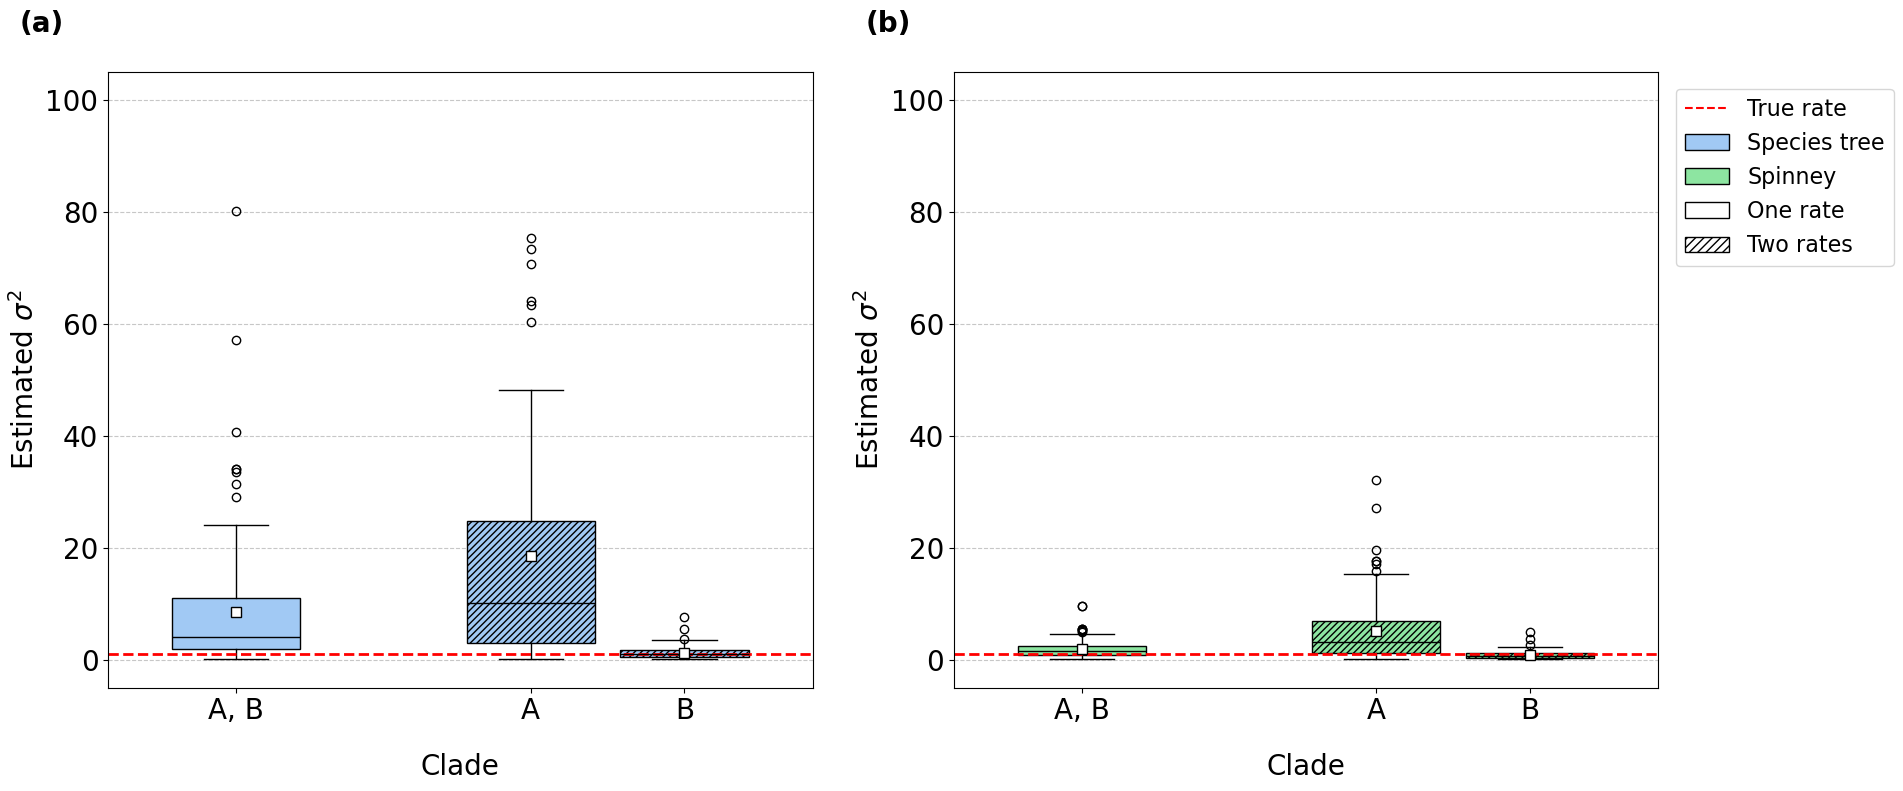

In [ ]:
tree_types = ["st", "sampled"]
tree_color = [species_tree_color, spinney_color]
ylims = [100, 100]
ylabels = [ "Species tree", "Spinney"]
figlabels = ["(a)", "(b)"]
# Create figure
fig, axes = plt.subplots(1,2, figsize=(20,8), dpi=100)
fontsize = 20

for ax, condition, color, ylim, ylabel, label in zip(axes, tree_types, tree_color, ylims, ylabels, figlabels):
    plt_df = pd.concat([
        data_1p[data_1p.condition == condition].rate.reset_index(drop=True), 
        data_2p[data_2p.condition == condition].rateA.reset_index(drop=True), 
        data_2p[data_2p.condition == condition].rateB.reset_index(drop=True),
        ], axis=1)

    long_df = plt_df.melt(var_name='category', value_name='values')
    long_df["category"] = long_df["category"].astype(str)

    positions = [.5, 2.8, 4]
    categories = ["rate", "rateA", "rateB"]

    meanprops = {'marker': 's', 'markerfacecolor': 'white', 
                'markeredgecolor': 'black', 'markersize': 7}

    for i, category in enumerate(categories):
        data = long_df[long_df["category"] == category]["values"]
        
        hatch = None
        if category in ["rateA", "rateB"]:
            hatch = "/////"   
        
        ax.boxplot(
            data, positions=[positions[i]], widths=1, patch_artist=True,
            boxprops=dict(facecolor=color, color='black', hatch=hatch),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            meanprops=meanprops, showmeans=True
        )

    ax.plot([-0.5, 5.5], [1,1], 'r--', linewidth=2, label="true rate")
    ax.set_xticks(positions, ['A, B', 'A', 'B'], fontsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.set_ylabel(r'Estimated $\sigma^2$', fontsize=fontsize)
    ax.set_xlabel("Clade", fontsize=fontsize, labelpad=20)
    ax.set_xlim([-0.5,5])
    ax.set_ylim([-1.5, ylim])

    ax.text(-0.125, 1.1, label, transform=ax.transAxes,
            horizontalalignment='left', verticalalignment='top',
            fontsize=fontsize, fontweight='bold'
            )
    if condition == 'sampled':
         ax.set_yticks([x for x in range(0,41,10)])



axes[0].grid(True, axis="y", linestyle="--", alpha=0.7)
axes[1].set_ylim(axes[0].get_ylim())
axes[1].set_yticks(axes[0].get_yticks()[1:])
axes[1].grid(True, axis="y", linestyle="--", alpha=0.7)

ymin, ymax = 0, 100

yrange = ymax - ymin
ymin -= 0.05 * yrange
ymax += 0.05 * yrange

for ax in axes:
    ax.set_ylim(ymin, ymax)


line_handle = mlines.Line2D([], [], color="red", linestyle="--", label="True rate")

box_A = mpatches.Patch(facecolor=species_tree_color, edgecolor="black", label="Species tree")
box_B = mpatches.Patch(facecolor=spinney_color, edgecolor="black", label="Spinney")

method_X = mpatches.Patch(facecolor="white", edgecolor="black", label="One rate")
method_Y = mpatches.Patch(facecolor="white", edgecolor="black", hatch="////", label="Two rates")

ax.legend(handles=[line_handle, box_A, box_B, method_X, method_Y],
          loc="upper right",fontsize=fontsize-4,  bbox_to_anchor=(1.35, 0.99),)

plt.show()



# Figure 6

In [46]:
condition_prefix = ("twoclade_condition4", "twoclade_condition2", "twoclade_condition3")
sigma2= [0.1, 1, 10]

selected_conditions  = [x for x in conditions if x.startswith(condition_prefix)]

data_1p = rate_1p.loc[rate_1p.condition.isin(selected_conditions)]
data_2p = rate_2p.loc[rate_2p.condition.isin(selected_conditions)]

In [47]:
# calculate false positives

## LRT calculation
def likelihood_ratio(llh_1p, llh_2p):
    return -2*( llh_1p-llh_2p )

def LRT_calc(llh_1p, llh_2p, threshold = 0.05):
    # LRT calculation
    LRs = [ likelihood_ratio(L1,L2) for L1, L2 in zip(llh_1p, llh_2p) ]
    p_vals = [ chi2.sf(LR, 1) for LR in LRs]
    #print(f"{sum([x < threshold for x in p_vals])} out of {len(p_vals)} cases are significant (p<{round(threshold,2)})")
    return p_vals


In [48]:
fontsize = 20
summary_false_positive = {condition :{} for condition in condition_prefix}
for var, condition in zip(sigma2, condition_prefix):
    pval_st = LRT_calc(-data_1p[data_1p.condition == '%s_st_1p'%condition].llh, 
                        -data_2p[data_2p.condition == '%s_st_2p'%condition].llh, )  
    pval_sy = LRT_calc(-data_1p[data_1p.condition == '%s_sampled_1p'%condition].llh, 
                        -data_2p[data_2p.condition == '%s_sampled_2p'%condition].llh, )
    summary_false_positive[condition].update({'st': sum([x < 0.05 for x in pval_st]),
                                            'sy': sum([x < 0.05 for x in pval_sy])
                                            })

total_fp = pd.DataFrame(summary_false_positive).T
total_fp

,st,sy
twoclade_condition4,31,14
twoclade_condition2,48,15
twoclade_condition3,33,12


/var/folders/f7/y1wwv8vd5pl_xm3q00hb3ftr0000gn/T/ipykernel_22689/994128001.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0.1, 1, 10], fontsize=fontsize)


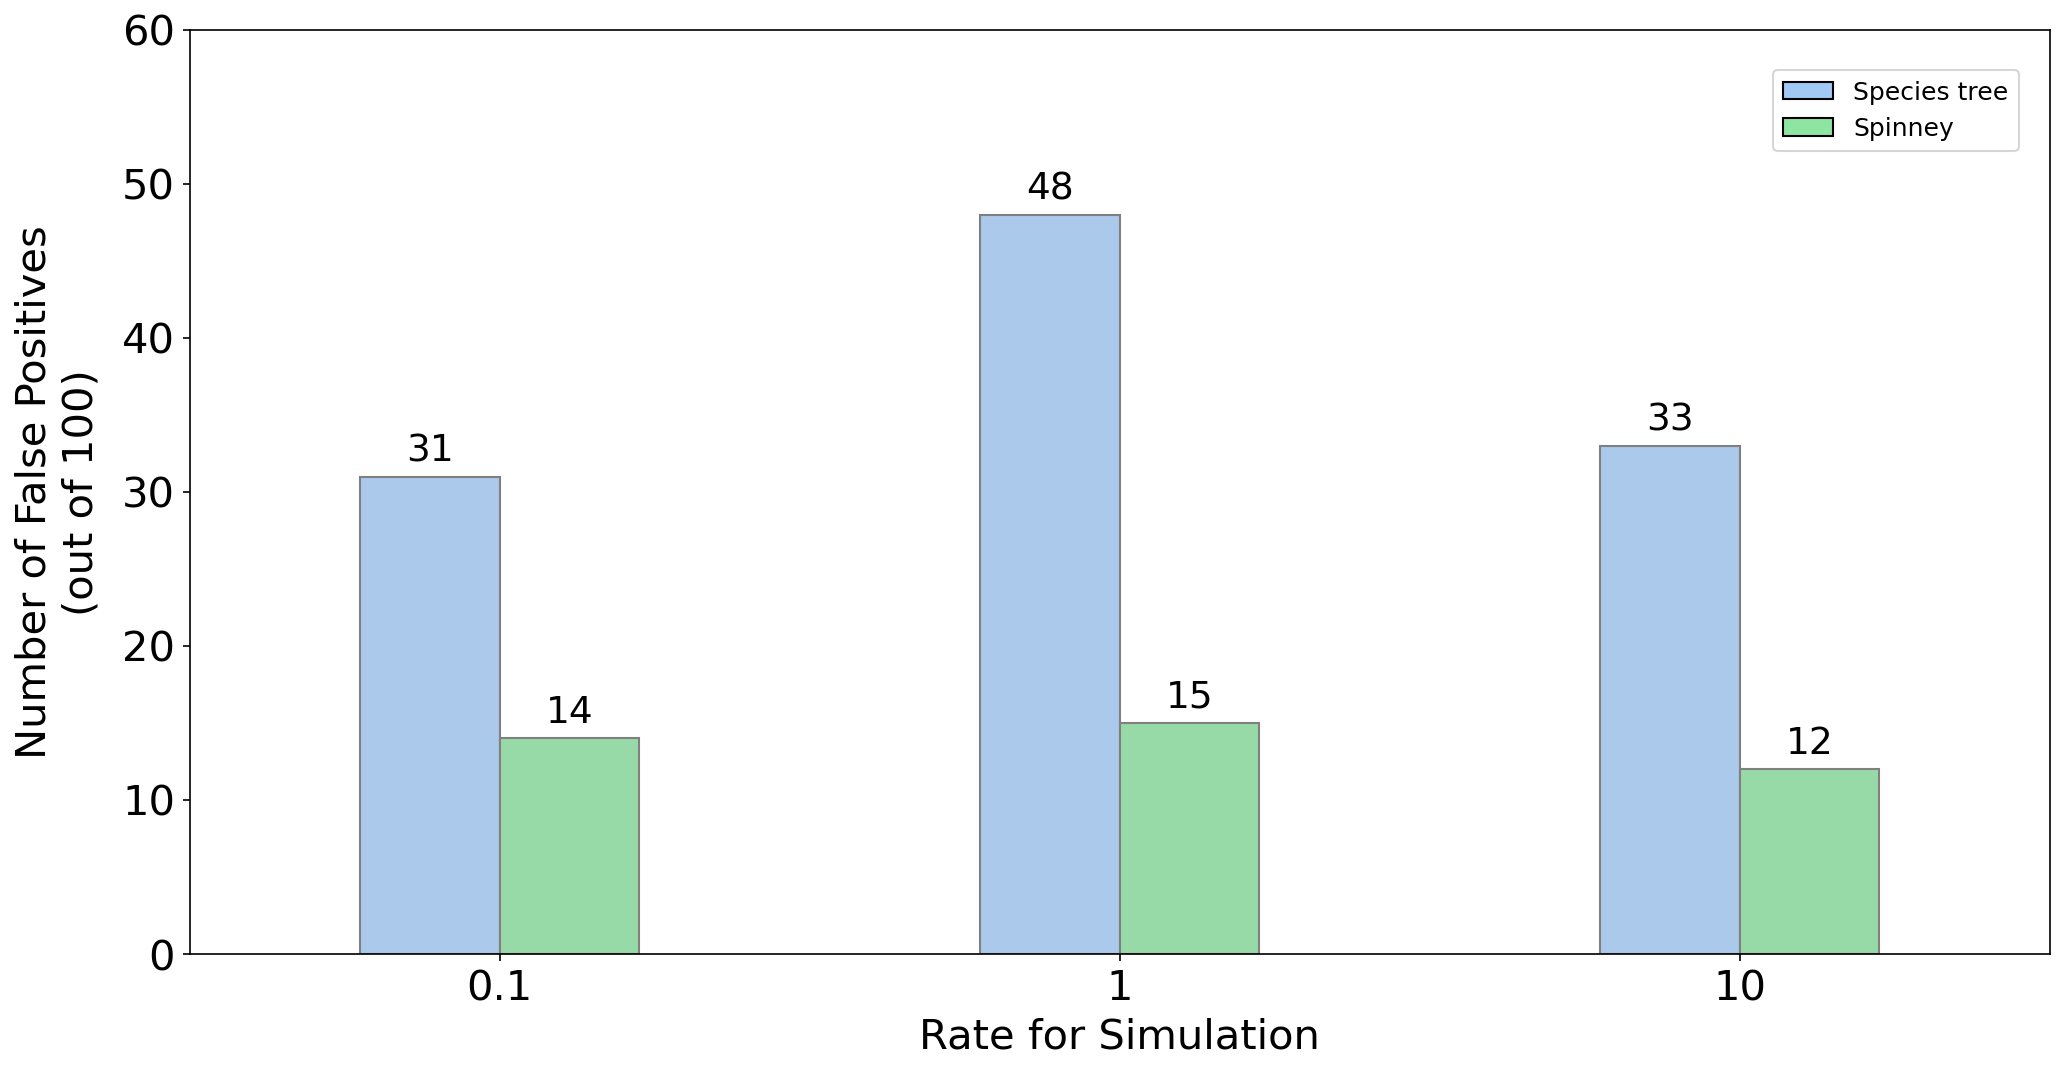

In [49]:
df_plot = total_fp.reset_index().melt(id_vars=["index"])

fontsize = 20
plt.figure(figsize=(16,8), dpi=150)

ax = sns.barplot(data= df_plot,
            x="index",
            y="value",
            hue="variable",
            palette=["#a1c9f4", "#8de5a1"],
            width=0.45,
            edgecolor = "gray"
            )

# Add bar height labels
for p in ax.patches[:6]:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.,  # x: center of bar
        height + 0.5,                    # y: slightly above bar
        f'{int(height)}',                # label text
        ha="center", va="bottom", fontsize=fontsize-2
    )

ax.set_xticklabels([0.1, 1, 10], fontsize=fontsize)

ax.set_xlabel("Rate for Simulation", fontsize=fontsize)
ax.set_ylabel("Number of False Positives\n(out of 100)", fontsize=fontsize, labelpad=10)
ax.set_ylim([0, 60])  # Set y-limit
ax.tick_params(axis='y', labelsize=fontsize)  # Adjust y-tick font size

# Custom legend outside

box_A = mpatches.Patch(facecolor=species_tree_color, edgecolor="black", label="Species tree")
box_B = mpatches.Patch(facecolor=spinney_color, edgecolor="black", label="Spinney")

ax.legend(handles=[box_A,box_B], fontsize=12,
          bbox_to_anchor=(0.99, 0.97),
          )

plt.show()

# Figure 7

## (a)

In [162]:
asr = pd.read_csv("ASR.csv")

groups = asr.groupby("condition")

for condi, group in groups:

    x = group[group.tree == "sampled"].loc[:, "CI_width"].reset_index(drop=True)
    y = group[group.tree == "st"].loc[:, "CI_width"].reset_index(drop=True)

    sy_vs_st = pd.concat([x,y], axis = 1)
    sy_vs_st.columns = ["sy", "st"]
    sy_vs_st.dropna(inplace=True)

    stat, pval = wilcoxon(sy_vs_st.st - sy_vs_st.sy, alternative="two-sided")

    print(f"{condi}: CI of spinney greater than CI of species tree (p value, {pval:.3e})")

high: CI of spinney greater than CI of species tree (p value, 8.861e-18)
low: CI of spinney greater than CI of species tree (p value, 9.015e-01)
med: CI of spinney greater than CI of species tree (p value, 5.760e-02)


/var/folders/f7/y1wwv8vd5pl_xm3q00hb3ftr0000gn/T/ipykernel_2738/1089043951.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Low", "Medium", "High"], fontsize=fontsize)


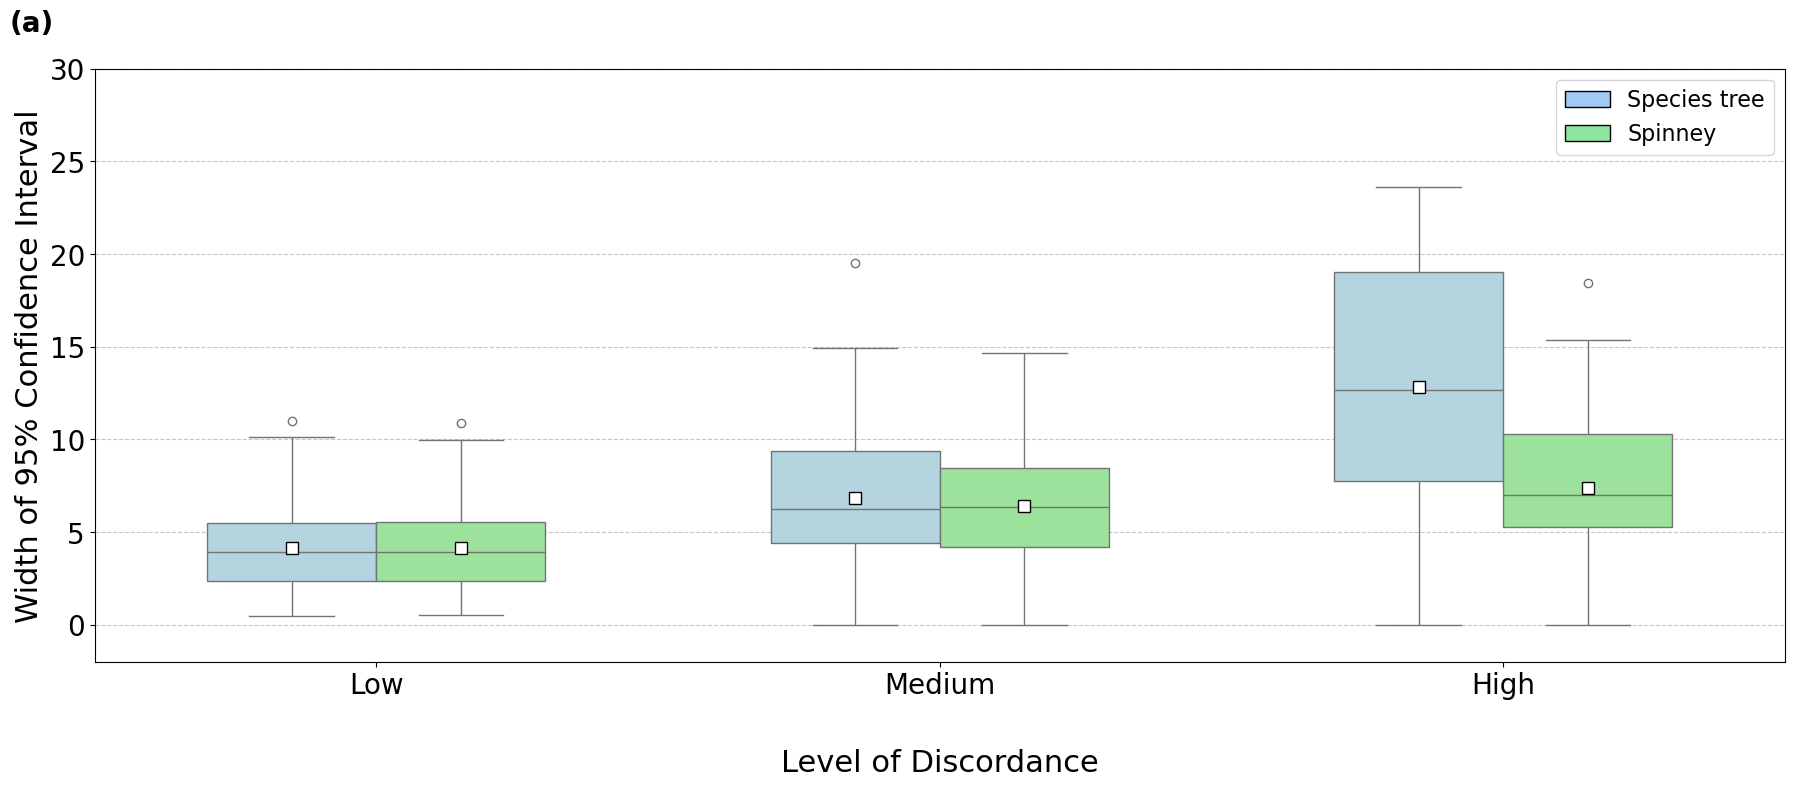

In [163]:
fontsize = 20
plt.figure(figsize=(20,8), dpi=100)

ax = sns.boxplot(
    data=asr, 
    x="condition",
    y="CI_width", 
    hue="tree",
    width=0.6,
    showmeans=True,
    palette=["lightblue", "lightgreen"],
    meanprops={'marker':'s','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'},
    legend=False
)


ax.set_xticklabels(["Low", "Medium", "High"], fontsize=fontsize)

ax.set_xlabel("Level of Discordance", fontsize=fontsize+2, labelpad=35)  # labelpad adds more distance
ax.set_ylabel("Width of 95% Confidence Interval", fontsize=fontsize+2)
ax.set_ylim([-2,30])
plt.yticks(fontsize=fontsize)

custom_legend = [
    plt.Line2D([0], [0], color="lightblue", lw=10, label="Species tree"),
    plt.Line2D([0], [0], color="lightgreen", lw=10, label="Spinney"),
]
ax.legend(handles=custom_legend, fontsize=16,
          bbox_to_anchor=(0.865, 0.97),
          borderaxespad=0)


ax.text(-0.05, 1.1, "(a)", transform=ax.transAxes,
        horizontalalignment='left', verticalalignment='top',
        fontsize=fontsize, fontweight='bold'
        )

box_A = mpatches.Patch(facecolor=species_tree_color, edgecolor="black", label="Species tree")
box_B = mpatches.Patch(facecolor=spinney_color, edgecolor="black", label="Spinney")
ax.legend(handles=[box_A, box_B],
          loc="upper right",fontsize=fontsize-4)

plt.grid(True, axis='y', linestyle="--", alpha=0.7)


plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


## (b) and (c)


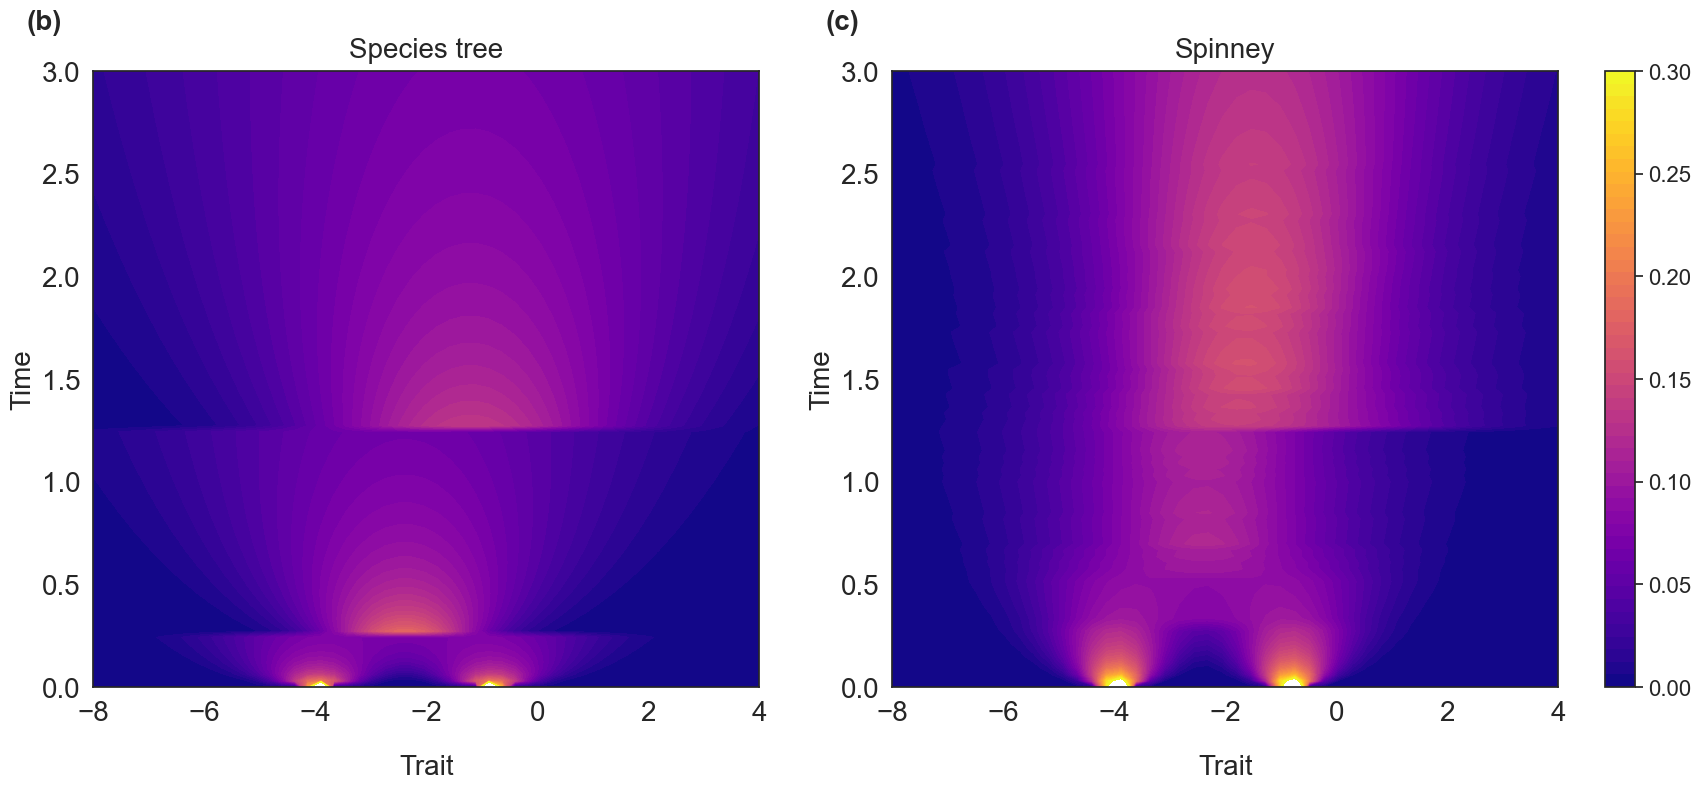

In [8]:
from spinney.utils import ancestral_state_pipeline

CONFIG = {"condition": "fourtaxa_med",  
          "speciation_time": 1.25,  
          "final_time": 3, 
          "num_slicing": 100, 
          "traits": [49], 
          "base_dir": "../single_rate/fourtaxa_med" 
          }


fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=100)

_, cs1 = ancestral_state_pipeline(
    CONFIG,
    prefix="fourtaxa_med",
    treetype="st",
    trait_ids=[49],
    lower=20,
    higher=80,
    ax=axes[0],
)

_, cs2 = ancestral_state_pipeline(
    CONFIG,
    prefix="fourtaxa_med",
    treetype="sy",
    trait_ids=[49],
    lower=20,
    higher=80,
    ax=axes[1],
)

xmins = [ax.get_xlim()[0] for ax in axes]
xmaxs = [ax.get_xlim()[1] for ax in axes]
xmin, xmax = max(xmins), min(xmaxs)

xmin_int = int(np.ceil(xmin))
xmax_int = int(np.floor(xmax))

xticks = np.arange(xmin_int, xmax_int, 2)
xticks = np.arange(-8, 5, 2)

for ax in axes:
    ax.set_xlim(xmin_int, xmax_int)
    ax.set_xticks(xticks)

labels = ["(b)", "(c)"]
for lb, ax in zip(labels, axes):
    ax.text(-0.1, 1.1, lb, transform=ax.transAxes,
                ha='left', va='top', fontsize=20, fontweight='bold')

plt.subplots_adjust(wspace=0.2)

cbar = fig.colorbar(
    cs2,
    ax=axes,                 
    orientation="vertical",
    fraction=0.025,          
    pad=.03
)

cbar.set_ticks(np.arange(0, 0.31, 0.05))
cbar.ax.tick_params(labelsize=16)

for panel_idx, ttl in enumerate(["Species tree", "Spinney"]):
    axes[panel_idx].set_title(ttl, fontsize=20, pad=10)